# Scenario Analysis — Oil Market Regime Identification

This notebook identifies oil market regimes using two indices:
- **OVX**: CBOE Oil Volatility Index — captures uncertainty/fear in oil markets
- **Brent 12-month spread**: Spot minus 12-month futures — positive = backwardation, negative = contango

The two indices together define four quadrants:

| | Low OVX | High OVX |
|---|---|---|
| **Backwardation** | Calm supply tightness | Crisis backwardation (supply shock) |
| **Contango** | Calm oversupply | Crisis contango (demand collapse) |

The three target episodes are shaded on the chart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

A4_W, A4_H = 11.69, 8.27  # landscape A4

## 1. Load Data

In [2]:
# OVX
ovx = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')
ovx['date'] = pd.to_datetime(ovx['date'])
ovx = ovx.rename(columns={'OVXCLS': 'ovx'})

# Oil spot and 12-month futures
spot = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
spot['date'] = pd.to_datetime(spot['date'])
spot = spot[['date', 'Brent']]

fut = pd.read_csv('../data/processed/Oil/oil_futures.csv')
fut['date'] = pd.to_datetime(fut['date'])
fut = fut[['date', 'Brent_12m']]

# Merge
df = ovx.merge(spot, on='date', how='inner')
df = df.merge(fut,  on='date', how='inner')
df = df.sort_values('date').reset_index(drop=True)

# Compute spread: positive = backwardation, negative = contango
df['spread'] = df['Brent'] - df['Brent_12m']

# Resample to weekly
df = df.set_index('date').resample('W').last().reset_index()
df = df.dropna(subset=['ovx', 'spread'])

# Sample period
df = df[(df['date'] >= '2015-01-01') & (df['date'] <= '2024-12-31')]

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Observations: {len(df)}")
print(f"OVX range:    {df['ovx'].min():.1f} – {df['ovx'].max():.1f}")
print(f"Spread range: {df['spread'].min():.2f} – {df['spread'].max():.2f}")

Date range: 2015-01-04 to 2024-12-29
Observations: 522
OVX range:    19.3 – 190.1
Spread range: -14.20 – 24.96


## 2. Define Episodes

In [3]:
EPISODES = {
    'Contango\n2015–2016': {
        'start':  '2015-01-01',
        'end':    '2016-12-31',
        'color':  '#2166AC',   # blue
        'alpha':  0.25,
        'description': 'Prolonged oversupply. OPEC refuses to cut. Persistent contango.'
    },
    'High OVX\nOct–Dec 2018': {
        'start':  '2018-10-01',
        'end':    '2018-12-31',
        'color':  '#D6604D',   # red
        'alpha':  0.35,
        'description': 'Demand crash. US-China trade war. OVX spike. No COVID confound.'
    },
    'Backwardation\nFeb–May 2022': {
        'start':  '2022-02-01',
        'end':    '2022-05-31',
        'color':  '#1A9850',   # green
        'alpha':  0.30,
        'description': 'Russia invasion. Supply shock. Extreme backwardation. OVX spike.'
    },
}

## 3. Double-Index Chart

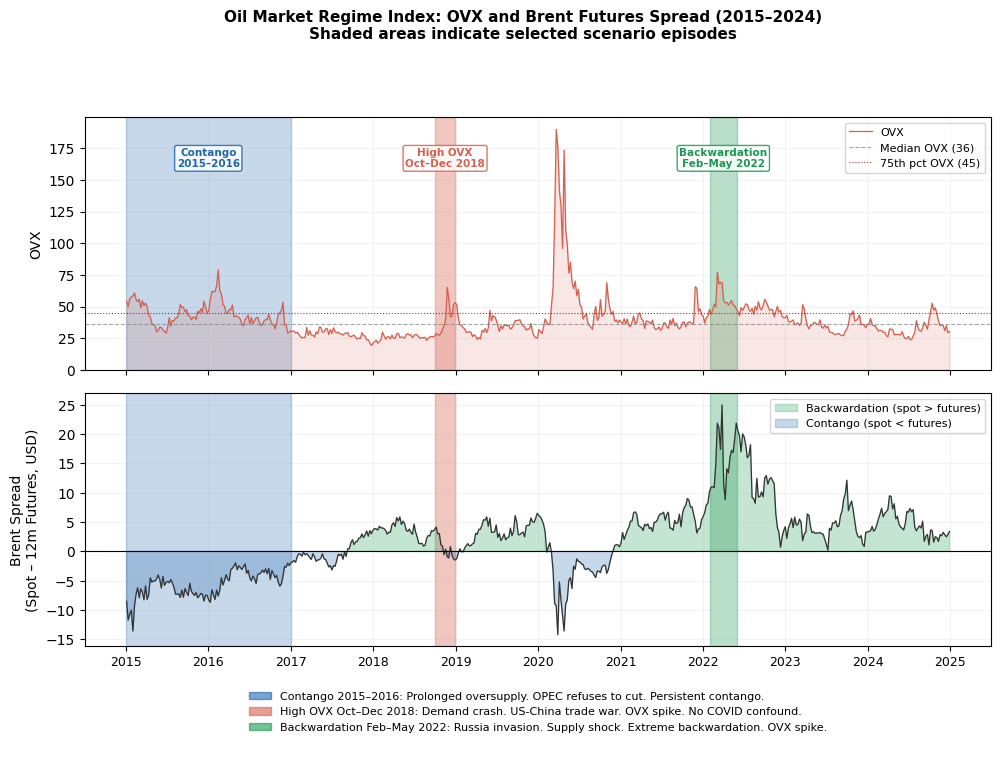

Saved.


In [4]:
fig = plt.figure(figsize=(A4_W, A4_H))
gs  = gridspec.GridSpec(
    3, 1,
    figure=fig,
    height_ratios=[1.8, 1.8, 0.6],
    hspace=0.12
)

ax_ovx    = fig.add_subplot(gs[0])
ax_spread = fig.add_subplot(gs[1], sharex=ax_ovx)
ax_legend = fig.add_subplot(gs[2])
ax_legend.axis('off')

# ── OVX panel ─────────────────────────────────────────────────
ax_ovx.fill_between(df['date'], df['ovx'],
                    alpha=0.15, color='#D6604D')
ax_ovx.plot(df['date'], df['ovx'],
            color='#D6604D', lw=0.9, label='OVX')

# OVX threshold lines
ovx_median = df['ovx'].median()
ovx_p75    = df['ovx'].quantile(0.75)
ax_ovx.axhline(ovx_median, color='grey', lw=0.8,
               linestyle='--', alpha=0.7,
               label=f'Median OVX ({ovx_median:.0f})')
ax_ovx.axhline(ovx_p75, color='#8B0000', lw=0.8,
               linestyle=':', alpha=0.8,
               label=f'75th pct OVX ({ovx_p75:.0f})')

ax_ovx.set_ylabel('OVX', fontsize=10)
ax_ovx.set_ylim(bottom=0)
ax_ovx.grid(True, alpha=0.15)
ax_ovx.legend(fontsize=8, loc='upper right', framealpha=0.8)
ax_ovx.tick_params(labelbottom=False)

# ── Spread panel ───────────────────────────────────────────────
# Fill positive (backwardation) green, negative (contango) blue
ax_spread.fill_between(df['date'], df['spread'],
                       where=df['spread'] >= 0,
                       alpha=0.25, color='#1A9850',
                       label='Backwardation (spot > futures)')
ax_spread.fill_between(df['date'], df['spread'],
                       where=df['spread'] < 0,
                       alpha=0.25, color='#2166AC',
                       label='Contango (spot < futures)')
ax_spread.plot(df['date'], df['spread'],
               color='#333333', lw=0.9)
ax_spread.axhline(0, color='black', lw=0.8, linestyle='-')

ax_spread.set_ylabel('Brent Spread\n(Spot – 12m Futures, USD)', fontsize=10)
ax_spread.grid(True, alpha=0.15)
ax_spread.legend(fontsize=8, loc='upper right', framealpha=0.8)

# ── Episode shading on both panels ────────────────────────────
for ep_label, ep in EPISODES.items():
    for ax in [ax_ovx, ax_spread]:
        ax.axvspan(
            pd.Timestamp(ep['start']),
            pd.Timestamp(ep['end']),
            alpha=ep['alpha'],
            color=ep['color'],
            zorder=0
        )

    # Label at top of OVX panel
    mid = pd.Timestamp(ep['start']) + (
        pd.Timestamp(ep['end']) - pd.Timestamp(ep['start'])
    ) / 2
    ax_ovx.text(
        mid, ax_ovx.get_ylim()[1] * 0.88,
        ep_label,
        ha='center', va='top',
        fontsize=7.5, fontweight='bold',
        color=ep['color'],
        bbox=dict(boxstyle='round,pad=0.2',
                  facecolor='white',
                  edgecolor=ep['color'],
                  alpha=0.85)
    )

# ── X-axis formatting ──────────────────────────────────────────
ax_spread.xaxis.set_major_locator(mdates.YearLocator())
ax_spread.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_spread.tick_params(axis='x', labelsize=9)

# ── Legend panel ───────────────────────────────────────────────
patches = [
    mpatches.Patch(color=ep['color'], alpha=0.6,
                   label=f"{ep_label.replace(chr(10), ' ')}: {ep['description']}")
    for ep_label, ep in EPISODES.items()
]
ax_legend.legend(
    handles=patches,
    loc='center',
    ncol=1,
    fontsize=8,
    frameon=False
)

# ── Title ──────────────────────────────────────────────────────
fig.suptitle(
    'Oil Market Regime Index: OVX and Brent Futures Spread (2015–2024)\n'
    'Shaded areas indicate selected scenario episodes',
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig('../output/figures/regime_index.pdf',
            bbox_inches='tight', dpi=200)
plt.savefig('../output/figures/regime_index.png',
            bbox_inches='tight', dpi=200)
plt.show()
print("Saved.")

## 4. Episode Summary Statistics

Confirms the regime characterisation numerically.

Saved: ../output/figures/scenario_contango_2016.pdf


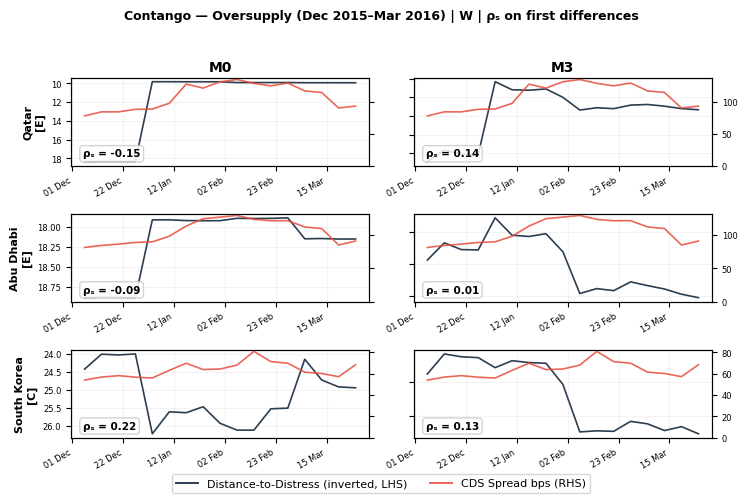

Saved: ../output/figures/scenario_ovx_2018.pdf


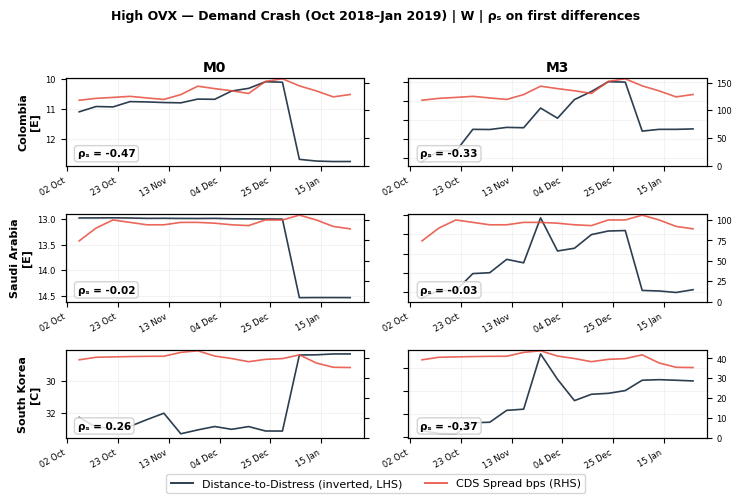

Saved: ../output/figures/scenario_covid_2020.pdf


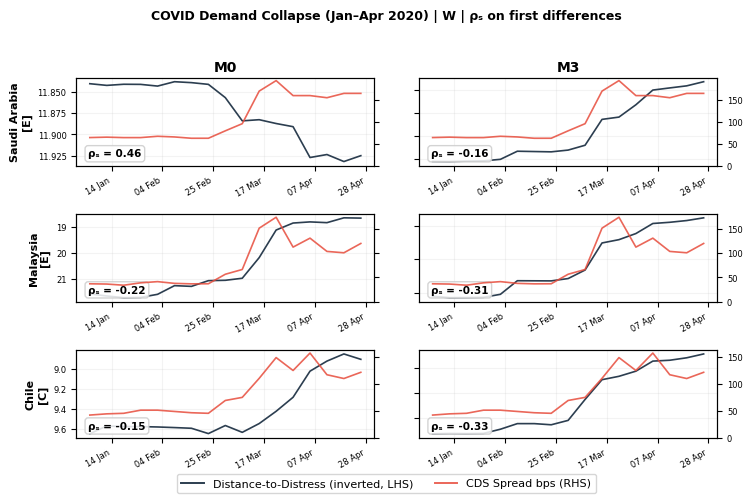

Saved: ../output/figures/scenario_backwardation_2022.pdf


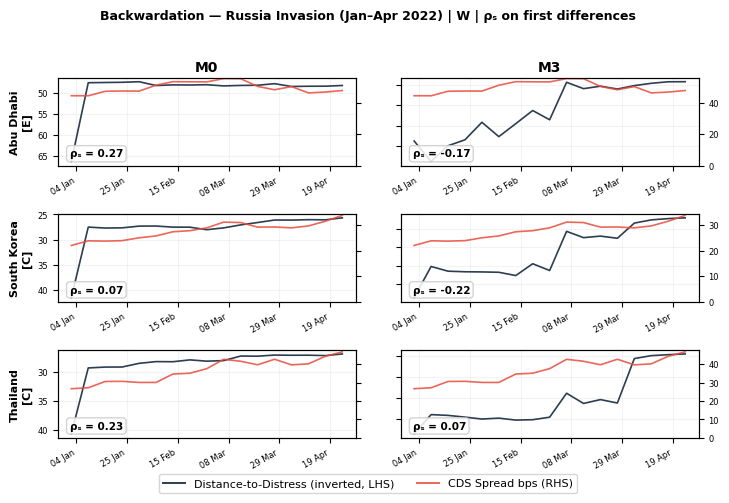

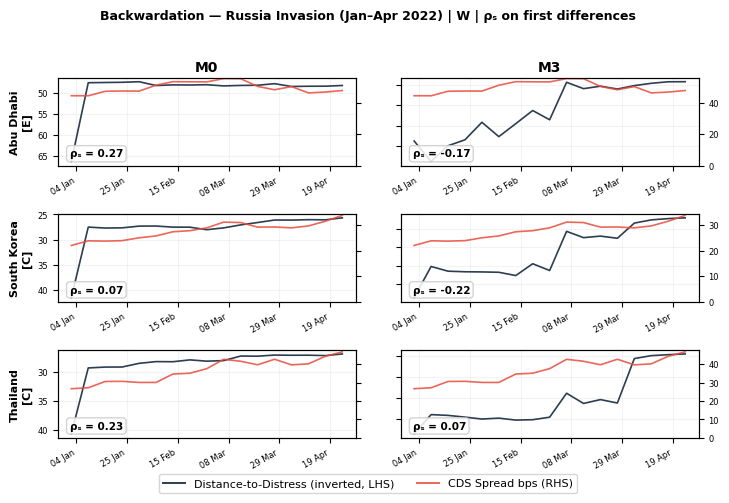

In [5]:
# ──────────────────────────────────────────────────────────────
# M0 vs M3 — Episode Tracking Comparison
# DD (inverted) vs CDS for selected countries
# Same plot_episode_grid function from CCA_results.ipynb
# ──────────────────────────────────────────────────────────────

from scipy.stats import spearmanr
import matplotlib.dates as mdates

# Load M0 and M3 only
dfs_scenario = {
    'M0': pd.read_csv('../output/results/M0_results.csv',
                      parse_dates=['date']),
    'M3': pd.read_csv('../output/results/M3_results.csv',
                      parse_dates=['date']),
}

A4_W, A4_H = 8.27, 11.69

EXPORTERS = [
    'Saudi Arabia', 'Abu Dhabi', 'Qatar',
    'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia',
]
CONTROLS = [
    'Indonesia', 'Philippines', 'Turkey', 'South Korea',
    'Chile', 'China', 'South Africa', 'Thailand',
]


def plot_episode_grid(models_dict, episode_countries,
                      episode_label, start_date, end_date,
                      freq='W', save_path=None):
    model_names = list(models_dict.keys())
    nrows = len(episode_countries)
    ncols = len(model_names)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(A4_W, A4_H * max(nrows / 8, 0.4)),
        gridspec_kw={'hspace': 0.55, 'wspace': 0.15}
    )

    # Normalise axes to 2D array
    if nrows == 1 and ncols == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [axes]
    elif ncols == 1:
        axes = [[ax] for ax in axes]

    for row, (country, grp_label) in enumerate(episode_countries):
        for col, mname in enumerate(model_names):
            ax1 = axes[row][col]
            ax2 = ax1.twinx()

            d = (models_dict[mname]
                 [models_dict[mname]['country'] == country]
                 .sort_values('date').copy())
            d['date'] = pd.to_datetime(d['date'])
            d = (d[(d['date'] >= start_date) &
                   (d['date'] <= end_date)]
                 .set_index('date')
                 .resample(freq).last()
                 .reset_index())

            if d.empty or len(d) < 5:
                ax1.text(0.5, 0.5, 'No data',
                         ha='center', va='center',
                         transform=ax1.transAxes, fontsize=8)
                continue

            ax1.plot(d['date'], d['distance_to_distress'],
                     color='#2C3E50', lw=1.2)
            ax2.plot(d['date'], d['cds_spread'],
                     color='#E74C3C', lw=1.2, alpha=0.85)
            ax2.set_ylim(bottom=0)
            ax1.invert_yaxis()

            ax1.tick_params(labelsize=6)
            ax2.tick_params(labelsize=6)

            if freq == 'W':
                ax1.xaxis.set_major_locator(
                    mdates.WeekdayLocator(interval=3))
                ax1.xaxis.set_major_formatter(
                    mdates.DateFormatter('%d %b'))
            else:
                ax1.xaxis.set_major_locator(
                    mdates.MonthLocator(interval=2))
                ax1.xaxis.set_major_formatter(
                    mdates.DateFormatter('%b %Y'))

            plt.setp(ax1.xaxis.get_majorticklabels(),
                     rotation=30, ha='right')
            ax1.grid(True, alpha=0.15)

            # Country label left column only
            if col == 0:
                ax1.set_ylabel(
                    f'{country}\n[{grp_label}]',
                    fontsize=8, fontweight='bold', labelpad=4
                )
            else:
                ax1.set_yticklabels([])

            # Model label top row only
            if row == 0:
                ax1.set_title(mname, fontsize=10,
                              fontweight='bold', pad=5)

            # Hide right axis ticks except last column
            if col < ncols - 1:
                ax2.set_yticklabels([])

            # Spearman rho on first differences
            valid = d.dropna(
                subset=['distance_to_distress', 'cds_spread'])
            if len(valid) > 5:
                diffs = (valid[['distance_to_distress',
                                'cds_spread']]
                         .diff().dropna())
                rho, _ = spearmanr(
                    diffs['distance_to_distress'],
                    diffs['cds_spread']
                )
                ax1.text(
                    0.04, 0.10, f'ρₛ = {rho:.2f}',
                    transform=ax1.transAxes,
                    fontsize=7.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='white',
                              edgecolor='#cccccc',
                              alpha=0.85)
                )

    # Figure legend
    dd_line  = plt.Line2D([0], [0], color='#2C3E50', lw=1.4)
    cds_line = plt.Line2D([0], [0], color='#E74C3C',
                          lw=1.4, alpha=0.85)
    fig.legend(
        [dd_line, cds_line],
        ['Distance-to-Distress (inverted, LHS)',
         'CDS Spread bps (RHS)'],
        loc='lower center', ncol=2, fontsize=8,
        bbox_to_anchor=(0.5, -0.02),
        frameon=True, edgecolor='#cccccc'
    )
    fig.text(
        0.5, 1.005,
        f'{episode_label} | {freq} | ρₛ on first differences',
        ha='center', fontsize=9, fontweight='bold'
    )

    if save_path:
        fig.savefig(save_path, dpi=200,
                    bbox_inches='tight', format='pdf')
        print(f'Saved: {save_path}')
    plt.show()
    return fig


# ── Episode 1: Contango / Oversupply (Dec 2015–Mar 2016) ──────
# M1 story: exporters where futures adjustment should activate
# Qatar and Abu Dhabi both show positive M0 during this period

plot_episode_grid(
    dfs_scenario,
    [('Qatar',       'E'),
     ('Abu Dhabi',   'E'),
     ('South Korea', 'C')],
    episode_label='Contango — Oversupply (Dec 2015–Mar 2016)',
    start_date='2015-12-01',
    end_date='2016-03-31',
    freq='W',
    save_path='../output/figures/scenario_contango_2016.pdf'
)

# ── Episode 2: High OVX — Demand Crash (Oct 2018–Jan 2019) ────
# M2 story: jump channel activates during demand-driven OVX spike
# Colombia (exporter) vs South Korea (control) — both should improve

plot_episode_grid(
    dfs_scenario,
    [('Colombia',    'E'),
     ('Saudi Arabia','E'),
     ('South Korea', 'C')],
    episode_label='High OVX — Demand Crash (Oct 2018–Jan 2019)',
    start_date='2018-10-01',
    end_date='2019-01-31',
    freq='W',
    save_path='../output/figures/scenario_ovx_2018.pdf'
)

# ── Episode 3: COVID demand collapse (Jan–Apr 2020) ────────────
# Both channels fire: OVX explodes + curve moves to extreme contango
# Saudi Arabia: M0 near zero (peg), M3 should rescue entirely

plot_episode_grid(
    dfs_scenario,
    [('Saudi Arabia', 'E'),
     ('Malaysia',     'E'),
     ('Chile',        'C')],
    episode_label='COVID Demand Collapse (Jan–Apr 2020)',
    start_date='2020-01-01',
    end_date='2020-04-30',
    freq='W',
    save_path='../output/figures/scenario_covid_2020.pdf'
)

# ── Episode 4: Backwardation — Russia invasion (Jan–Apr 2022) ──
# M2 dominant: OVX spikes + extreme backwardation
# M1 breaks down for some exporters (geopolitical contamination)
# Abu Dhabi vs South Korea + Thailand

plot_episode_grid(
    dfs_scenario,
    [('Abu Dhabi',   'E'),
     ('South Korea', 'C'),
     ('Thailand',    'C')],
    episode_label='Backwardation — Russia Invasion (Jan–Apr 2022)',
    start_date='2022-01-01',
    end_date='2022-04-30',
    freq='W',
    save_path='../output/figures/scenario_backwardation_2022.pdf'
)